In [1]:
from dotenv import load_dotenv

# Load OPENAI_API_KEY (and any other secrets) from a local .env file.
load_dotenv()


True

# Notebook 4 · Team (Modular) Multi-Agent System

> **Series:** LangChain MAS Architectures · Travel Agency Use Case

---

## Architecture Overview

In a **team MAS** each agent owns exactly one non-overlapping section of a
shared project board. Work flows as a fixed relay: each specialist fills their
section and the enriched board is passed to the next node automatically.

```
START
  └──► destination_node
              └──► flight_node
                        └──► hotel_node
                                   └──► activity_node
                                               └──► summarizer_node
                                                           └──► END

       each node owns one state field · pure relay · no coordinator
```

## Why LangGraph fits here

The relay order is not a *decision*, it is a structural
dependency (`flight` needs `destination`; `activities` needs `destination`).
Hard-coding decisions in prompts is fragile; encoding them in **graph edges**
makes the structure explicit, inspectable, and unambiguous.

With **LangGraph** the five `add_edge` calls *are* the coordination.
No LLM is involved in routing — the graph topology enforces the relay.

## Pattern in this notebook

| LangGraph concept | Role in team MAS |
|---|---|
| `TypedDict` state | One `str` field per board section (5 fields) |
| `StateGraph` nodes | One node per specialist + one summarizer |
| `add_edge` (×5) | Fixed linear relay — no conditionals needed |
| `summarizer_node` | Itinerary formatting, replaces the coordinator |


## 1 · Setup

In [2]:
# ── Traveler request ─────────────────────────────────────────────────────────
USER_REQUEST = """\
Plan a 4-day spring trip from Rome.
Requirements:
- mid-range budget
- easy flights
- central hotel
- mix of food and culture
- simple daily plan""".strip()

# ── Static catalog ────────────────────────────────────────────────────────────
DESTINATIONS = {
    "Lisbon":    {"best_period": "April-June", "style": "sunny, walkable, relaxed",
                  "notes": "great for food, viewpoints, and compact neighborhoods"},
    "Barcelona": {"best_period": "April-June", "style": "lively, artistic, seaside",
                  "notes": "strong mix of architecture, beach walks, and tapas"},
    "Prague":    {"best_period": "April-June", "style": "historic, compact, lower-cost",
                  "notes": "easy sightseeing with a classic old-town atmosphere"},
}

FLIGHTS = [
    {"destination": "Lisbon",    "code": "TP-833", "price": 180, "type": "direct",  "duration": "3h 05m"},
    {"destination": "Lisbon",    "code": "IB-310", "price": 150, "type": "1 stop",  "duration": "5h 10m"},
    {"destination": "Barcelona", "code": "VY-611", "price": 140, "type": "direct",  "duration": "1h 50m"},
    {"destination": "Barcelona", "code": "IB-220", "price": 125, "type": "1 stop",  "duration": "4h 00m"},
    {"destination": "Prague",    "code": "FR-721", "price": 110, "type": "direct",  "duration": "1h 55m"},
    {"destination": "Prague",    "code": "OS-410", "price": 145, "type": "1 stop",  "duration": "3h 45m"},
]

HOTELS = [
    {"destination": "Lisbon",    "name": "Baixa Stay",       "price_per_night": 145, "style": "central boutique hotel"},
    {"destination": "Lisbon",    "name": "River Rooms",       "price_per_night": 120, "style": "simple hotel near transit"},
    {"destination": "Barcelona", "name": "Born Hotel",        "price_per_night": 160, "style": "central design hotel"},
    {"destination": "Barcelona", "name": "Gracia Inn",        "price_per_night": 130, "style": "quiet hotel in a walkable district"},
    {"destination": "Prague",    "name": "Old Town House",    "price_per_night": 115, "style": "historic hotel near main sights"},
    {"destination": "Prague",    "name": "City Garden Hotel", "price_per_night":  95, "style": "budget-friendly hotel with tram access"},
]

ACTIVITIES = [
    {"destination": "Lisbon",    "name": "Alfama food walk",                    "tag": "food",    "price": 35},
    {"destination": "Lisbon",    "name": "Belem and river tram day",            "tag": "culture", "price": 25},
    {"destination": "Barcelona", "name": "Gothic Quarter tapas evening",        "tag": "food",    "price": 40},
    {"destination": "Barcelona", "name": "Sagrada Familia and modernism route", "tag": "culture", "price": 32},
    {"destination": "Prague",    "name": "Old Town walking tour",               "tag": "culture", "price": 18},
    {"destination": "Prague",    "name": "Czech dinner and jazz night",         "tag": "food",    "price": 30},
]

def flights_for(destination):    return [f for f in FLIGHTS    if f["destination"] == destination]
def hotels_for(destination):     return [h for h in HOTELS     if h["destination"] == destination]
def activities_for(destination): return [a for a in ACTIVITIES if a["destination"] == destination]

def catalog_text():
    lines = []
    for dest, info in DESTINATIONS.items():
        lines.append(f"Destination: {dest}")
        lines.append(f"  Best period : {info['best_period']}")
        lines.append(f"  Style       : {info['style']}")
        lines.append(f"  Notes       : {info['notes']}")
        lines.append("  Flights:")
        for f in flights_for(dest):
            lines.append(f"    - {f['code']} | {f['type']} | EUR {f['price']} | {f['duration']}")
        lines.append("  Hotels:")
        for h in hotels_for(dest):
            lines.append(f"    - {h['name']} | EUR {h['price_per_night']}/night | {h['style']}")
        lines.append("  Activities:")
        for a in activities_for(dest):
            lines.append(f"    - {a['name']} | {a['tag']} | EUR {a['price']}")
        lines.append("")
    return "\n".join(lines).strip()

CATALOG_TEXT = catalog_text()

print("USER_REQUEST:")
print(USER_REQUEST)
print("\nCatalog loaded - destinations:", list(DESTINATIONS.keys()))


USER_REQUEST:
Plan a 4-day spring trip from Rome.
Requirements:
- mid-range budget
- easy flights
- central hotel
- mix of food and culture
- simple daily plan

Catalog loaded - destinations: ['Lisbon', 'Barcelona', 'Prague']


## 2 · Graph State

`TeamState` is a plain `TypedDict` with one `str` field per board section.

The key architectural insight: **section ownership is encoded in the state
schema itself**. Each specialist node writes to exactly one field.
All other fields stay unchanged — not because of a prompt instruction, but
because the node function simply does not return them.

```
TeamState
  destination_and_period  ←  destination_node writes here
  flight                  ←  flight_node writes here
  hotel                   ←  hotel_node writes here
  activities              ←  activity_node writes here
  final_writeup           ←  summarizer_node writes here
```


In [3]:
from typing_extensions import TypedDict

# Plain TypedDict — no AgentState, no reducers needed.
# Each field is a simple string written once by one specialist node.
class TeamState(TypedDict):
    destination_and_period: str   # <- destination_node
    flight:                 str   # <- flight_node
    hotel:                  str   # <- hotel_node
    activities:             str   # <- activity_node
    final_writeup:          str   # <- summarizer_node


## 3 · Specialist Agents

Five `create_agent` instances — one per specialist role.
Each has a tightly scoped system prompt that:

1. Names the agent's **single owned section** explicitly.
2. Tells the agent to read but **not modify** any other section.
3. Only allows options from the static catalog.

No coordinator tells these agents what to do. The graph edge is what
causes each agent to run — not a prompt instruction from another LLM.


In [4]:
from langchain.agents import create_agent

destination_designer = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    system_prompt=(
        "You are the Destination Designer in a modular travel-agency team.\n"
        "You own exactly one section of the project board: 'destination_and_period'.\n"
        "Read the traveler request and catalog, then write your section ONLY.\n"
        "Do NOT mention flights, hotels, or activities.\n"
        "Only use destinations listed in the catalog."
    ),
)

flight_specialist = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    system_prompt=(
        "You are the Flight Specialist in a modular travel-agency team.\n"
        "You own exactly one section: 'flight'.\n"
        "The destination has already been chosen (it is in the board you receive).\n"
        "Choose ONE flight for that destination. Write the 'flight' section ONLY.\n"
        "Only use flights listed in the catalog."
    ),
)

hotel_specialist = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    system_prompt=(
        "You are the Hotel Specialist in a modular travel-agency team.\n"
        "You own exactly one section: 'hotel'.\n"
        "The destination has already been chosen (it is in the board you receive).\n"
        "Choose ONE hotel for that destination. Write the 'hotel' section ONLY.\n"
        "Only use hotels listed in the catalog."
    ),
)

activity_specialist = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    system_prompt=(
        "You are the Activity Specialist in a modular travel-agency team.\n"
        "You own exactly one section: 'activities'.\n"
        "The destination has already been chosen (it is in the board you receive).\n"
        "Choose 2-3 activities (food + culture mix). Write the 'activities' section ONLY.\n"
        "Only use activities listed in the catalog."
    ),
)

print("Specialist agents defined.")


Specialist agents defined.


## 4 · Node Functions

Each node is a plain **async Python function** that:

1. Renders the current board state as text (so the specialist sees earlier sections).
2. Invokes its specialist agent with a `HumanMessage`.
3. Returns a dict with **exactly one key** — the section this node owns.

LangGraph merges that dict into the shared state. All other state fields are
untouched because the node does not return them.

> **No ToolRuntime, no Command, no coordinator.**
> The edge topology is the coordination. The node function is just the agent call.

### The `_board_text` helper

Specialists downstream of `destination_node` need to see which destination was
chosen. `_board_text` renders the full current state as readable text, making
earlier sections visible to later nodes — exactly the relay property.


In [5]:
from langchain.messages import HumanMessage

# ── Helper: render the full board for downstream specialists ──────────────────
def _board_text(state: TeamState) -> str:
    fields = [
        "destination_and_period",
        "flight",
        "hotel",
        "activities",
        "final_writeup",
    ]
    lines = []
    for f in fields:
        val = state.get(f, "") or "(not filled yet)"
        lines.append(f"  {f}: {val}")
    return "\n".join(lines)


# ── Node: destination_designer ────────────────────────────────────────────────
# Runs first — no upstream sections to read (board is empty).
async def destination_node(state: TeamState) -> dict:
    print("--- destination_node ---")

    response = await destination_designer.ainvoke({
        "messages": [HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Catalog:\n{CATALOG_TEXT}\n\n"
            f"Project board (current state):\n{_board_text(state)}\n\n"
            "Write the 'destination_and_period' section."
        ))]
    })
    return {"destination_and_period": response["messages"][-1].content}


# ── Node: flight_specialist ───────────────────────────────────────────────────
# Reads destination_and_period (already filled by destination_node).
async def flight_node(state: TeamState) -> dict:
    print("--- flight_node ---")

    response = await flight_specialist.ainvoke({
        "messages": [HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Catalog:\n{CATALOG_TEXT}\n\n"
            f"Project board (current state):\n{_board_text(state)}\n\n"
            "Write the 'flight' section."
        ))]
    })
    return {"flight": response["messages"][-1].content}


# ── Node: hotel_specialist ────────────────────────────────────────────────────
# Reads destination_and_period and flight (both filled upstream).
async def hotel_node(state: TeamState) -> dict:
    print("--- hotel_node ---")

    response = await hotel_specialist.ainvoke({
        "messages": [HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Catalog:\n{CATALOG_TEXT}\n\n"
            f"Project board (current state):\n{_board_text(state)}\n\n"
            "Write the 'hotel' section."
        ))]
    })
    return {"hotel": response["messages"][-1].content}


# ── Node: activity_specialist ─────────────────────────────────────────────────
# Reads destination, flight, hotel — all filled upstream.
async def activity_node(state: TeamState) -> dict:
    print("--- activity_node ---")

    response = await activity_specialist.ainvoke({
        "messages": [HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Catalog:\n{CATALOG_TEXT}\n\n"
            f"Project board (current state):\n{_board_text(state)}\n\n"
            "Write the 'activities' section."
        ))]
    })
    return {"activities": response["messages"][-1].content}


# ── Node: summarizer ──────────────────────────────────────────────────────────
# All four specialist sections are filled. Render a clean client itinerary.
# This node replaces the coordinator's final step — without being a coordinator.
async def summarizer_node(state: TeamState) -> dict:
    print("--- summarizer_node ---")

    from langchain.chat_models import init_chat_model
    from langchain.messages import SystemMessage
    model = init_chat_model("openai:gpt-4.1-mini", temperature=0)

    result = await model.ainvoke([
        SystemMessage(content=(
            "You are a formatting assistant. "
            "Turn the completed project board into one clean, client-ready 4-day itinerary. "
            "Do NOT change any decisions already recorded on the board."
        )),
        HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Completed project board:\n{_board_text(state)}"
        )),
    ])
    return {"final_writeup": result.content}

print("Node functions defined.")


Node functions defined.


## 5 · Build the Graph

Five `add_edge` calls are the entire coordination layer.
There are **no conditional edges**, no routing functions, no LLM deciding what
comes next — the dependency order is encoded directly in the graph structure.

```
START → destination_node → flight_node → hotel_node → activity_node → summarizer_node → END
```

Compare this to the previous version where a `create_agent` coordinator had a
numbered list in its prompt instructing it to call specialists in order.
Here the same ordering is expressed as immutable graph topology — inspectable
with a single `draw_mermaid_png()` call.


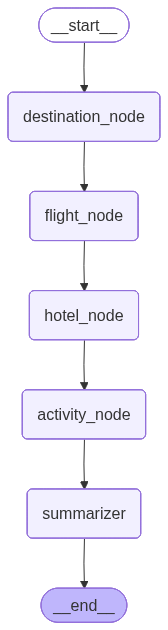

In [6]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Initialise the graph with the team state schema.
builder = StateGraph(TeamState)

# ── Register every specialist as a node ───────────────────────────────────────
builder.add_node("destination_node", destination_node)
builder.add_node("flight_node",      flight_node)
builder.add_node("hotel_node",       hotel_node)
builder.add_node("activity_node",    activity_node)
builder.add_node("summarizer",       summarizer_node)

# ── Fixed relay edges — this IS the coordination ──────────────────────────────
# No routing functions, no conditionals, no LLM deciding the order.
# The dependency structure (destination first, itinerary last) is encoded here.
builder.add_edge(START,              "destination_node")
builder.add_edge("destination_node", "flight_node")
builder.add_edge("flight_node",      "hotel_node")
builder.add_edge("hotel_node",       "activity_node")
builder.add_edge("activity_node",    "summarizer")
builder.add_edge("summarizer",       END)

# ── Compile and visualise ─────────────────────────────────────────────────────
graph = builder.compile()

# The Mermaid diagram shows the exact relay chain — fully transparent.
display(Image(graph.get_graph().draw_mermaid_png()))


## 6 · Run

Initial state has all fields empty. Each node fills exactly one field,
and the updated state flows to the next node automatically via the edges.


In [7]:
initial_state = {
    "destination_and_period": "",
    "flight":                 "",
    "hotel":                  "",
    "activities":             "",
    "final_writeup":          "",
}

result = await graph.ainvoke(initial_state)


--- destination_node ---
--- flight_node ---
--- hotel_node ---
--- activity_node ---
--- summarizer_node ---


In [8]:
from pprint import pprint

# Full state after the graph completes
pprint(result)


{'activities': 'activities:\n'
               '  - Old Town walking tour | culture | EUR 18\n'
               '  - Czech dinner and jazz night | food | EUR 30',
 'destination_and_period': 'destination_and_period: \n'
                           '  Destination: Prague\n'
                           '  Travel Period: April (spring) - ideal for '
                           'historic charm and comfortable weather\n'
                           '  Notes: Prague offers a lower-cost, historic, and '
                           'compact city experience perfect for a 4-day trip. '
                           'It combines culture and food easily with a simple '
                           'daily plan, and flights from Rome are direct and '
                           'short.',
 'final_writeup': '4-Day Spring Itinerary: Rome to Prague\n'
                  '\n'
                  'Day 1: Arrival and Old Town Exploration\n'
                  '- Flight: Depart Rome on direct flight FR-721 to Prague (1h '
  

In [9]:
# Inspect each board section individually
print("=" * 60)
print("PROJECT BOARD (section by section)")
print("=" * 60)
for field in ["destination_and_period", "flight", "hotel", "activities"]:
    print(f"\n-- {field} --")
    print(result[field])


PROJECT BOARD (section by section)

-- destination_and_period --
destination_and_period: 
  Destination: Prague
  Travel Period: April (spring) - ideal for historic charm and comfortable weather
  Notes: Prague offers a lower-cost, historic, and compact city experience perfect for a 4-day trip. It combines culture and food easily with a simple daily plan, and flights from Rome are direct and short.

-- flight --
flight:
  Flight Number: FR-721
  Route: Rome to Prague, direct
  Cost: EUR 110
  Duration: 1h 55m
  Notes: Direct flight with a short duration, fitting the preference for easy flights and a mid-range budget.

-- hotel --
hotel:
  Name: Old Town House
  Cost: EUR 115/night
  Description: Historic hotel near main sights, offering a central location perfect for exploring Prague's charming old town on foot. Ideal for travelers seeking a blend of culture and comfort within a mid-range budget.

-- activities --
activities:
  - Old Town walking tour | culture | EUR 18
  - Czech dinne

In [10]:
# Final client-ready itinerary
print("=" * 60)
print("FINAL ITINERARY")
print("=" * 60)
print(result["final_writeup"])


FINAL ITINERARY
4-Day Spring Itinerary: Rome to Prague

Day 1: Arrival and Old Town Exploration
- Flight: Depart Rome on direct flight FR-721 to Prague (1h 55m, EUR 110).
- Check-in at Old Town House hotel (EUR 115/night), centrally located in Prague’s historic district.
- Afternoon: Take a leisurely Old Town walking tour to immerse yourself in Prague’s rich culture and history (EUR 18).
- Evening: Enjoy a relaxing Czech dinner accompanied by live jazz music, experiencing local flavors and ambiance (EUR 30).

Day 2: Cultural Immersion and Local Cuisine
- Morning: Explore Prague Castle and St. Vitus Cathedral at your own pace.
- Afternoon: Visit the Jewish Quarter and its museums.
- Evening: Dine at a traditional Czech restaurant near the hotel, sampling classic dishes.

Day 3: Art, History, and Culinary Delights
- Morning: Visit the National Gallery or the Museum of Communism.
- Afternoon: Stroll across Charles Bridge and relax in Kampa Park.
- Evening: Try a modern Czech bistro for di

## 7 · Key Takeaways

| What you saw | Why it matters |
|---|---|
| `StateGraph` with `TypedDict` | Pure LangGraph state — no `AgentState`, no `ToolRuntime` |
| Each node returns **one key** | Ownership encoded in code, not in a prompt instruction |
| Five `add_edge` calls = coordination | The relay order is graph topology, not an LLM decision |
| `_board_text(state)` | Later specialists read upstream results directly from state |
| `summarizer_node` | Formatting step at the end — never a decision-maker |

### Contrast with the previous version

| Aspect | Previous (coordinator) | This version (LangGraph) |
|---|---|---|
| Relay ordering | Coordinator prompt listed tools 1-5 | Five `add_edge` calls in `StateGraph` |
| State updates | `Command(update={"field": ...})` inside tools | Node returns `{"field": value}` directly |
| Summarising | Coordinator LLM wrote the final output | Dedicated `summarizer_node` (non-agent) |
| Inspectability | Hidden in a prompt string | `draw_mermaid_png()` shows the full graph |

---

## Series Summary

| | Flat (nb 1) | Hierarchical (nb 2) | Society (nb 3) | Team (nb 4) |
|---|---|---|---|---|
| Topology | Cyclic graph | Star (manager-centered) | Ballot + winner | Linear pipeline |
| Coordination | Conditional edge | Manager `create_agent` | Vote counter agent | Fixed `add_edge` chain |
| Stops when | All peers vote ready | Manager done | Majority reached | Pipeline complete |
| Key LangGraph feature | `add_conditional_edges` loop | `create_agent` + `state_schema` | `Command` + `declare_winner` | Plain `add_edge` sequence |
